## Static Word Embeddings: Word2Vec & GloVe

This Jupyter Notebook explores **static word embeddings**, including:
1. Introduction to static word embeddings
2. Word2Vec model (pre-trained & custom training)
3. GloVe embeddings (pre-trained & custom training)
4. Visualizing word embeddings with PCA & t-SNE

Static word embeddings assign **a single vector representation to each word**, independent of context.


In [ ]:
# Install required packages (uncomment if needed)
# !pip install gensim numpy matplotlib seaborn sklearn

In [1]:
# Import necessary libraries
import numpy as np
import gensim.downloader as api
import matplotlib.pyplot as plt
import seaborn as sns
from gensim.models import Word2Vec, KeyedVectors
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

### **1. Load Pre-Trained Word2Vec Embeddings**

Word2Vec is a neural network-based model that learns word associations from large text corpora.
Pre-trained embeddings can be loaded from `gensim`.


In [2]:
# Load Google's pre-trained Word2Vec model (300-dimensional vectors, ~3GB)
w2v_model = api.load("word2vec-google-news-300")

# Check vector for a word
word = "king"
print(f"Vector for '{word}':", w2v_model[word])

# Find similar words
print("Words similar to 'king':", w2v_model.most_similar(word))

Vector for 'king': [ 1.25976562e-01  2.97851562e-02  8.60595703e-03  1.39648438e-01
 -2.56347656e-02 -3.61328125e-02  1.11816406e-01 -1.98242188e-01
  5.12695312e-02  3.63281250e-01 -2.42187500e-01 -3.02734375e-01
 -1.77734375e-01 -2.49023438e-02 -1.67968750e-01 -1.69921875e-01
  3.46679688e-02  5.21850586e-03  4.63867188e-02  1.28906250e-01
  1.36718750e-01  1.12792969e-01  5.95703125e-02  1.36718750e-01
  1.01074219e-01 -1.76757812e-01 -2.51953125e-01  5.98144531e-02
  3.41796875e-01 -3.11279297e-02  1.04492188e-01  6.17675781e-02
  1.24511719e-01  4.00390625e-01 -3.22265625e-01  8.39843750e-02
  3.90625000e-02  5.85937500e-03  7.03125000e-02  1.72851562e-01
  1.38671875e-01 -2.31445312e-01  2.83203125e-01  1.42578125e-01
  3.41796875e-01 -2.39257812e-02 -1.09863281e-01  3.32031250e-02
 -5.46875000e-02  1.53198242e-02 -1.62109375e-01  1.58203125e-01
 -2.59765625e-01  2.01416016e-02 -1.63085938e-01  1.35803223e-03
 -1.44531250e-01 -5.68847656e-02  4.29687500e-02 -2.46582031e-02
  1.85

### **2. Train a Custom Word2Vec Model**

Train a Word2Vec model using a small custom dataset.


In [7]:
# Example sentences
documents = [["dog", "barks"], ["cat", "meows"], ["bird", "flies"], ["fish", "swims"], ["dog", "runs"], ["cat", "jumps"]]

# Train Word2Vec
custom_w2v = Word2Vec(sentences=documents, vector_size=50, window=5, min_count=1, workers=4)

# Get vector for 'dog'
print("Vector for 'dog':", custom_w2v.wv["dog"])

# Most similar word to 'dog'
print("Most similar to 'dog':", custom_w2v.wv.most_similar("dog", topn=1))

Vector for 'dog': [-0.01631583  0.0089916  -0.00827415  0.00164907  0.01699724 -0.00892435
  0.009035   -0.01357392 -0.00709698  0.01879702 -0.00315531  0.00064274
 -0.00828126 -0.01536538 -0.00301602  0.00493959 -0.00177605  0.01106732
 -0.00548595  0.00452013  0.01091159  0.01669191 -0.00290748 -0.01841629
  0.0087411   0.00114357  0.01488382 -0.00162657 -0.00527683 -0.01750602
 -0.00171311  0.00565313  0.01080286  0.01410531 -0.01140624  0.00371764
  0.01217773 -0.0095961  -0.00621452  0.01359526  0.00326295  0.00037983
  0.00694727  0.00043555  0.01923765  0.01012121 -0.01783478 -0.01408312
  0.00180291  0.01278507]
Most similar to 'dog': [('swims', 0.12486252188682556)]


### **3. Load Pre-Trained GloVe Embeddings**

GloVe (Global Vectors for Word Representation) is based on word co-occurrence statistics.


In [ ]:
# Download & load GloVe embeddings (50-dimensional for faster processing)
def load_glove_model(glove_file):
    embeddings = {}
    with open(glove_file, "r", encoding="utf-8") as f:
        for line in f:
            values = line.split()
            word = values[0]
            vector = np.asarray(values[1:], dtype='float32')
            embeddings[word] = vector
    return embeddings

# Load a small GloVe model (update path if needed)
# glove_model = load_glove_model("glove.6B.50d.txt")
# print("Vector for 'king':", glove_model['king'])

### **4. Visualizing Word Embeddings with PCA & t-SNE**

Word embeddings exist in high-dimensional space (300D for Word2Vec/GloVe).
PCA and t-SNE are used to reduce dimensionality for visualization.


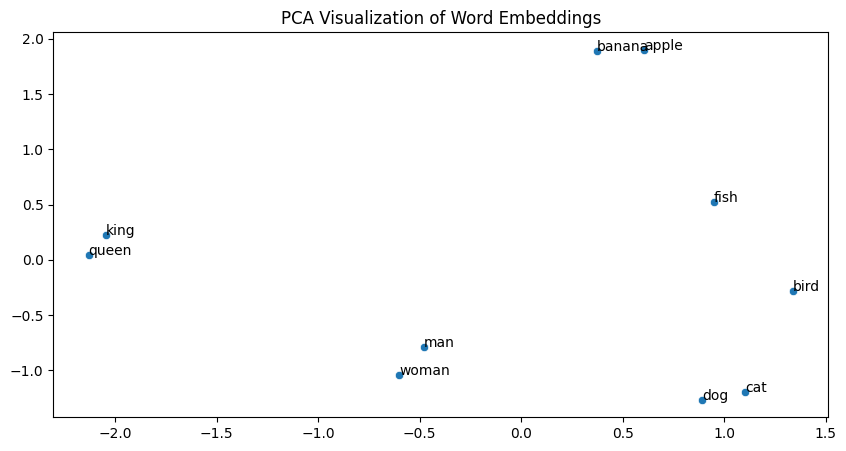

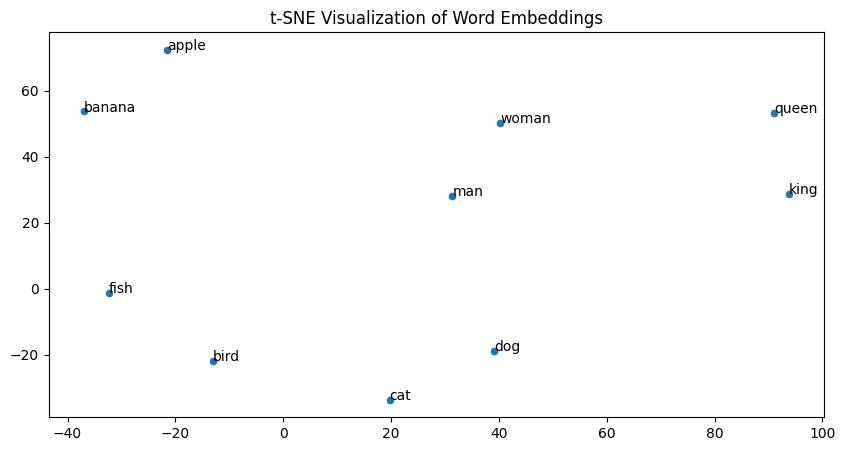

In [6]:
# Select words for visualization
words = ["king", "queen", "man", "woman", "dog", "cat", "bird", "fish", "apple", "banana"]
word_vectors = np.array([w2v_model[word] for word in words])

# PCA Reduction
pca = PCA(n_components=2)
pca_result = pca.fit_transform(word_vectors)

# t-SNE Reduction
tsne = TSNE(n_components=2, perplexity=5, random_state=42)
tsne_result = tsne.fit_transform(word_vectors)

# Plot PCA results
plt.figure(figsize=(10,5))
sns.scatterplot(x=pca_result[:,0], y=pca_result[:,1])
for i, word in enumerate(words):
    plt.annotate(word, (pca_result[i,0], pca_result[i,1]))
plt.title("PCA Visualization of Word Embeddings")
plt.show()

# Plot t-SNE results
plt.figure(figsize=(10,5))
sns.scatterplot(x=tsne_result[:,0], y=tsne_result[:,1])
for i, word in enumerate(words):
    plt.annotate(word, (tsne_result[i,0], tsne_result[i,1]))
plt.title("t-SNE Visualization of Word Embeddings")
plt.show()